# DATA ANALYSIS

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("CEAS_08.csv")

In [3]:
print(df.head())

                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                         receiver  \
0                     user4@gvc.ceas-challenge.cc   
1                   user2.2@gvc.ceas-challenge.cc   
2                   user2.9@gvc.ceas-challenge.cc   
3  SpamAssassin Dev <xrh@spamassassin.apache.org>   
4                   user2.2@gvc.ceas-challenge.cc   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28:00 -1200   
3  Tue, 05 Aug 2008 17:31:20 -0600   
4  Tue, 05 Aug 2008 19:31:21 -0400   

                                             subject  \
0                          Never agree to be a loser   
1  

In [4]:
print(df.shape)
print(df.columns)

(39154, 7)
Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 66.3 MB


dealing with missing values

In [6]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [7]:
df[df['receiver'].isnull()].head()

,sender,receiver,date,subject,body,label,urls
294,Tony Earnshaw <uhbyq@hetnet.nl>,NaN,"Wed, 06 Aug 2008 00:47:37 +0100",Re: [dkim-milter-discuss] postfix + dkim-filte...,"Daniel Black skrev, on 08-02-2008 13:19:\n> On...",0,0
335,Tony Earnshaw <uhbyq@hetnet.nl>,NaN,"Wed, 06 Aug 2008 00:49:33 +0100",Re: [dkim-milter-discuss] postfix + dkim-filte...,"Wietse Venema skrev, on 08-02-2008 14:48:\n> T...",0,0
601,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:04:34 +0100",Re: permission denied while using pipe in mast...,"Jordi Moles wrote:\n> Hi,\n>\n> the shellscrip...",0,0
611,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:04:58 +0100",Re: Forwarding all localmail,Randy Ramsdell wrote:\n> I would like to know ...,0,0
620,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:05:33 +0100",Re: SASL questions,"AlxFrag wrote:\n> Hi,\n>\n> i have a couple of...",0,0


In [8]:
df[df['subject'].isnull()].head()

,sender,receiver,date,subject,body,label,urls
1800,wblci-akz@cs.orst.edu,"""undisclosed-recipients: ;""@teff16.cs.uwaterlo...","Tue, 05 Aug 2008 17:22:26 -0700",NaN,Pattern Recognition Contest (PRC)\nSender: wbl...,0,1
2104,新桥学术翻译机构 <gzxqfy@163.com>,user7-ext3@gvc.ceas-challenge.cc,"Wed, 06 Aug 2008 09:32:45 +0800",NaN,\n\n\n\n\nGoing beyond the Words: Translations...,1,0
2352,Rachel Slater <sicewt.y.xiutff@gmail.com>,user2.1@gvc.ceas-challenge.cc,"Wed, 06 Aug 2008 14:46:50 +1300",NaN,Hi\n\nPlease do Brothers and Sisters for your ...,0,0
3677,The Doctor <phfvtn@doctor.nl2k.ab.ca>,zqoqi@spamassassin.apache.org,"Tue, 05 Aug 2008 20:18:29 -0700",NaN,Hmm!! Slight problem!\n\nI indicated a whtieli...,0,0
5940,garik magdalen <stemple@tirol.com>,user3@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 23:01:05 +0000",NaN,Be with me and over 2.100.000 gamers playing ...,1,0


In [9]:
# filling subject with empty string since other subjects would be useful but it is not needed
df['subject'] = df['subject'].fillna('')

In [10]:
# we can drop receiver since its not needed
df = df.drop(columns=['receiver'])

In [11]:
df.isnull().sum()

sender     0
date       0
subject    0
body       0
label      0
urls       0
dtype: int64

# Feature engineering

In [12]:
# Create a new column that stores the length of the email subject
# This can help detect phishing because phishing subjects are often short or very urgent
df['subject_len'] = df['subject'].str.len()

# Create a new column that stores the length of the email body
# Phishing emails sometimes have shorter bodies or repetitive text
df['body_len'] = df['body'].str.len()

# Combine the subject and body into one text column
# This will be used later for NLP processing (TF-IDF, vectorization, ML models)
df['text'] = df['subject'] + " " + df['body']

In [13]:
df[['subject_len','body_len','text']].head()

,subject_len,body_len,text
0,25,273,"Never agree to be a loser Buck up, your troubl..."
1,22,82,Befriend Jenna Jameson \nUpgrade your sex and ...
2,20,3918,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...
3,150,24418,Re: svn commit: r619753 - in /spamassassin/tru...
4,26,175,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...


In [14]:
# Count how many emails belong to each label (phishing vs legitimate)
# This helps check if the dataset is balanced or imbalanced
df['label'].value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

In [15]:
# Group the dataset by label and calculate the average number of URLs
# This helps determine if phishing emails tend to contain more links
df.groupby('label')['urls'].mean()

label
0    0.655210
1    0.681668
Name: urls, dtype: float64

In [16]:
# Group emails by label and compute the average subject length and body length
# This helps identify whether phishing emails are generally shorter or longer
df.groupby('label')[['subject_len','body_len']].mean()

,subject_len,body_len
label,,
0,48.084277,2542.186287
1,31.614321,801.379452


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

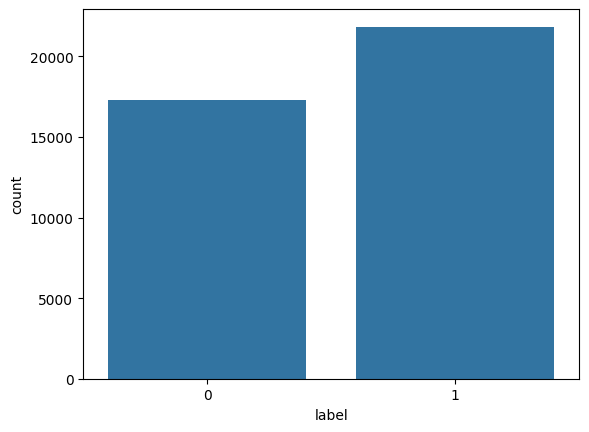

In [ ]:
sns.countplot(x='label', data=df)

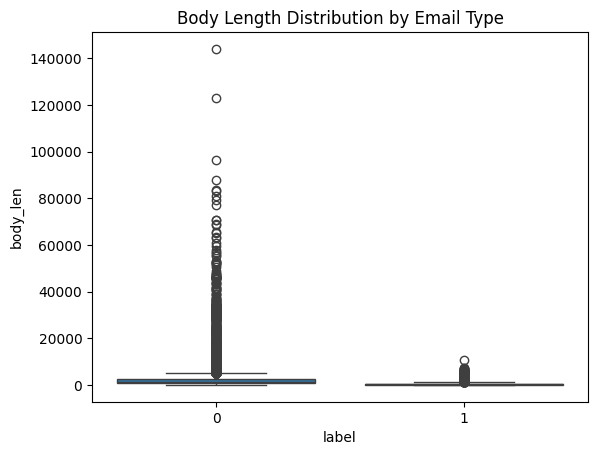

In [20]:
sns.boxplot(x='label', y='body_len', data=df)
plt.title("Body Length Distribution by Email Type")
plt.show()

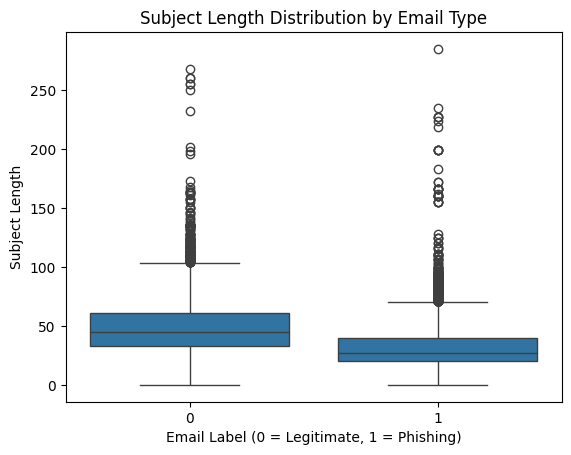

In [21]:
# Visualize subject length differences
sns.boxplot(x='label', y='subject_len', data=df)

plt.title("Subject Length Distribution by Email Type")
plt.xlabel("Email Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Subject Length")

plt.show()

In [22]:
from collections import Counter

phish_words = " ".join(df[df['label']==1]['text'])
Counter(phish_words.split()).most_common(20)

[('to', 34708),
 ('=', 29482),
 ('the', 28398),
 ('a', 26176),
 ('of', 25039),
 ('your', 22844),
 ('and', 22332),
 ('>', 14746),
 ('<', 14653),
 ('CNN.com', 14533),
 ('in', 13508),
 ('from', 13159),
 ('you', 12424),
 ('10', 11853),
 ('News', 11640),
 ('is', 11173),
 ('for', 10978),
 ('as', 10500),
 ('2008', 10001),
 ('To', 9801)]

In [24]:
# Most of these are stopwords which are common in emails we need to remove these from the data

In [25]:
import re
import nltk
from nltk.corpus import stopwords

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Totem\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [27]:
stop_words = set(stopwords.words('english'))

In [28]:
def clean_text(text):

    # convert text to lowercase
    text = text.lower()

    # remove numbers and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # split into words
    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # join words back into a string
    return " ".join(words)

In [29]:
df['clean_text'] = df['text'].apply(clean_text)

In [30]:
phish_words = " ".join(df[df['label']==1]['clean_text'])
Counter(phish_words.split()).most_common(20)

[('top', 18361),
 ('cnncom', 14533),
 ('news', 12863),
 ('cnn', 10153),
 ('daily', 8837),
 ('network', 8718),
 ('settings', 8677),
 ('cable', 8673),
 ('replica', 7730),
 ('alert', 7040),
 ('email', 6586),
 ('time', 6406),
 ('go', 6277),
 ('going', 5990),
 ('videos', 5929),
 ('lp', 5896),
 ('stories', 5864),
 ('lllp', 5860),
 ('one', 5828),
 ('custom', 5657)]

# Label Distribution
Phishing percentage: 21842 / 39154 ≈ 55.8%
Legitimate percentage: 17312 / 39154 ≈ 44.2%
Conclusion:

The dataset is fairly balanced.

No major class imbalance exists.

Therefore no resampling techniques (SMOTE/undersampling) are required.

# URL Analysis
Legitimate emails (0) → 0.655 URLs on average
Phishing emails (1) → 0.681 URLs on average

Interpretation:

Phishing emails contain slightly more URLs, but the difference is very small.

Conclusion:

URL count alone is not a strong indicator of phishing in this dataset.

# Subject Length Analysis
Legitimate → 48 characters
Phishing → 31 characters

Interpretation:

Legitimate emails:
Longer
More descriptive

Phishing emails:
Short
Urgent phrases

# Body Length Analysis
Legitimate → 2542 characters
Phishing → 801 characters

Interpretation:

Legitimate emails:
Longer conversations
Mailing lists
Technical discussions

Phishing emails:
Short
Template-based messages

Conclusion:
Body length is a very strong indicator.

In [33]:
# Convert the date column to datetime and standardize timezones
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# Extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Analyze phishing frequency by month
df.groupby('month')['label'].mean()

month
1.0     1.000000
2.0     1.000000
3.0     0.800000
4.0     0.947368
5.0     0.944444
6.0     0.945946
7.0     0.642276
8.0     0.555249
9.0     0.925926
10.0    1.000000
11.0    1.000000
12.0    1.000000
Name: label, dtype: float64

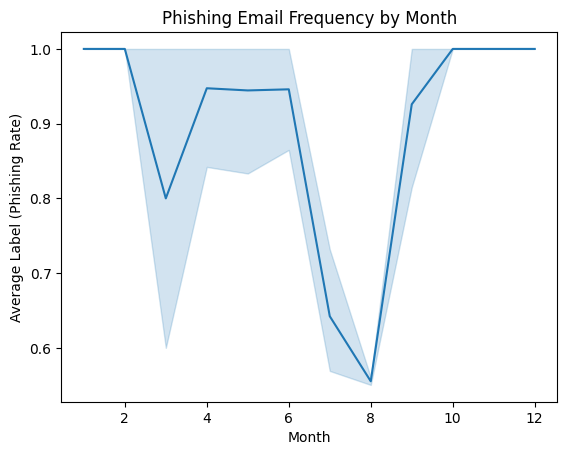

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='month', y='label', data=df)

plt.title("Phishing Email Frequency by Month")
plt.ylabel("Average Label (Phishing Rate)")
plt.xlabel("Month")

plt.show()

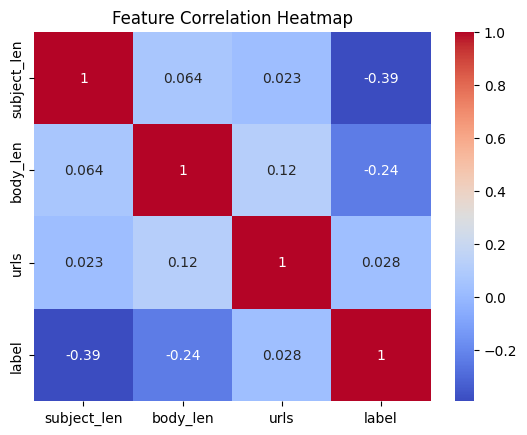

In [37]:
# correlation analysis

# Compute correlation matrix
corr_matrix = df[['subject_len','body_len','urls','label']].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

next steps:
clean_text
->
TF-IDF
->
train_test_split
->
Logistic Regression
->
evaluation

In [43]:
# Text column
text = df['clean_text']

# Target variable (1 = phishing, 0 = legitimate)
y = df['label']

In [44]:
from sklearn.model_selection import train_test_split

# First split: train+validation (80%) and test (20%)
text_train_val, text_test, y_train_val, y_test = train_test_split(
    text,
    y,
    test_size=0.2,
    random_state=42
)

# Second split: train (60%) and validation (20%)
text_train, text_val, y_train, y_val = train_test_split(
    text_train_val,
    y_train_val,
    test_size=0.25,   # 0.25 of 80% = 20%
    random_state=42
)

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

# Fit only on training data
X_train = vectorizer.fit_transform(text_train)

# Transform validation and test using the same vocabulary
X_val = vectorizer.transform(text_val)
X_test = vectorizer.transform(text_test)

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
from sklearn.metrics import accuracy_score

y_val_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.9923381432767208


### Logistic Regression Model Development Report

#### 1. Objective

The goal of this stage was to build a baseline machine learning model capable of classifying emails as **phishing (1)** or **legitimate (0)** using the cleaned email text.

---

#### 2. Dataset Preparation

The CEAS email dataset was used for the model. Before training the model, the following preprocessing steps were performed:

* Duplicate emails were removed to prevent training–validation leakage.
* The **clean_text** column was used as the input feature.
* The **label** column was used as the target variable, where:

  * `1 = phishing`
  * `0 = legitimate`.

Removing duplicates was necessary because identical emails appearing in both training and validation sets could artificially inflate model accuracy.

---

#### 3. Dataset Splitting

The dataset was split into three subsets:

* **Training set (60%)** – used to train the model.
* **Validation set (20%)** – used to evaluate the model during development.
* **Test set (20%)** – reserved for final performance evaluation.

This separation ensures that the model is evaluated on unseen data and prevents information leakage.

---

#### 4. Text Feature Extraction (TF-IDF)

Since machine learning models cannot directly process raw text, the cleaned email text was converted into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

Key configuration:

* `max_features = 5000`

The TF-IDF vectorizer was **fit only on the training data**, and the learned vocabulary was then applied to the validation and test sets to avoid data leakage.

---

#### 5. Model Training

A **Logistic Regression classifier** was used as the baseline model.

Configuration:

* `max_iter = 1000`

The model was trained using the TF-IDF features from the training dataset.

---

#### 6. Model Evaluation

The trained model was evaluated on the validation dataset. Predictions were generated and compared against the true labels to calculate the **validation accuracy**.

The validation accuracy obtained was approximately **99.23%**, indicating that the model performs very well at distinguishing phishing emails from legitimate ones in this dataset.

---

#### 7. Discussion

The high performance of the Logistic Regression model can be attributed to:

* Distinct vocabulary differences between phishing emails and legitimate mailing-list conversations.
* The effectiveness of TF-IDF in capturing word importance in email text.

Removing duplicate emails ensured that the model evaluation remained reliable and not artificially inflated.

---

#### 8. Next Steps

Future improvements to the model may include:

* Comparing performance with other classifiers such as **Multinomial Naive Bayes** or **Support Vector Machines**.
* Incorporating additional features such as:

  * subject length
  * body length
  * number of URLs
* Evaluating the model on the held-out **test dataset** for final performance assessment.
